Initial Dataset Shape: (5000, 7)

--- Model Metrics ---
Mean Squared Error (MSE): 10093927421.029875
Root Mean Squared Error (RMSE): 100468.53945902605
R2 Score: 0.9179571965141136

--- Correlation Matrix ---


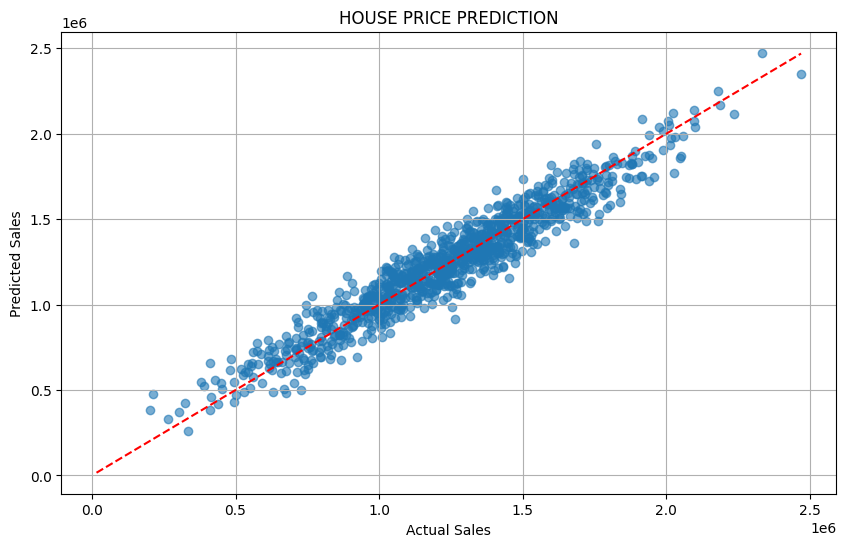

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1. Load Dataset
data_url = "https://raw.githubusercontent.com/Muralimekala/pythontrain/master/USA_Housing.csv"
df = pd.read_csv(data_url)
print("Initial Dataset Shape:", df.shape)

# 2. Feature Engineering from Address Column
df["State"] = df["Address"].str.extract(r"([A-Z]{2})\s+\d")
df["Zip_Code"] = df["Address"].str.extract(r"(\d{5})")
df["Is_Military"] = df["Address"].str.contains("FPO|APO|DPO|USS|USNS").astype(int)

# Drop original text address column
df.drop(columns=["Address"], inplace=True)

# Convert Zip_Code to numerical integer type
df["Zip_Code"] = df["Zip_Code"].astype(int)

# 3. Categorical Encoding (One-Hot Encoding for States)
og = OneHotEncoder(
    sparse_output=False, max_categories=10, handle_unknown="infrequent_if_exist"
)
encoded_cols = pd.DataFrame(
    og.fit_transform(df[["State"]]), columns=og.get_feature_names_out(["State"])
)

# Combine encoded features back into the main DataFrame
df = pd.concat([df.drop(columns=["State"]), encoded_cols], axis=1)

# 4. Feature and Target Splitting
x = df.drop(columns=["Price"])
y = df["Price"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# 5. Model Training
model = LinearRegression()
model.fit(x_train, y_train)

# 6. Model Evaluation
y_predict = model.predict(x_test)

mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predict)

print("\n--- Model Metrics ---")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R2 Score: {r2}")

print("\n--- Correlation Matrix ---")
#print(df.corr())

# 7. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predict, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--")
plt.title("HOUSE PRICE PREDICTION")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.grid(True)
plt.show()